## Task 2: Stock Price Prediction

**Objective:**  
Build a model to predict future stock prices based on historical stock data, including features like opening price, closing price, high, low, and trading volume.

**Tasks:**  
- Preprocess the data  
- Choose a suitable model (e.g., Linear Regression or LSTM)  
- Train the model  
- Evaluate its prediction accuracy

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Step 1: Download Historical Stock Data

In [ ]:
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-01-01")

# Display the first few rows
df.head()

/tmp/ipython-input-1008124594.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400
2022-01-05,171.165863,176.303187,170.891874,175.755209,94537600
2022-01-06,168.308472,171.537649,167.956198,168.993445,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


## Step 2: Explore the Dataset

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
# Create a target column: Prediction of the 'Close' price for the next day
df['Next_Close'] = df['Close'].shift(-1)

# Drop the last row as it won't have a 'Next_Close' value to predict
df = df.dropna()

## Step 3: Define Features and Target

In [ ]:
# We use Open, High, Low, Close, and Volume as specified in the task
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Next_Close']

## Step 4: Split Data into Training and Testing Sets

In [ ]:
# Time-Series Split: For stocks, we train on older data and test on newer data
# We do not shuffle the data to maintain the chronological order
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 400
Testing set size: 100


## Step 5: Train Linear Regression Model

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Output the coefficients for insights
print("Model Coefficients:", model.coef_)

Model Coefficients: [-1.67121458e-01 -1.94237065e-02  2.95557391e-01  8.70367037e-01
  2.06502741e-09]


## Step 6: Make Predictions

In [ ]:
predictions = model.predict(X_test)

## Step 7: Model Evaluation

In [ ]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 4.57
R-squared (R2) Score: 0.93


## Step 8: Visualization of Actual vs Predicted Prices

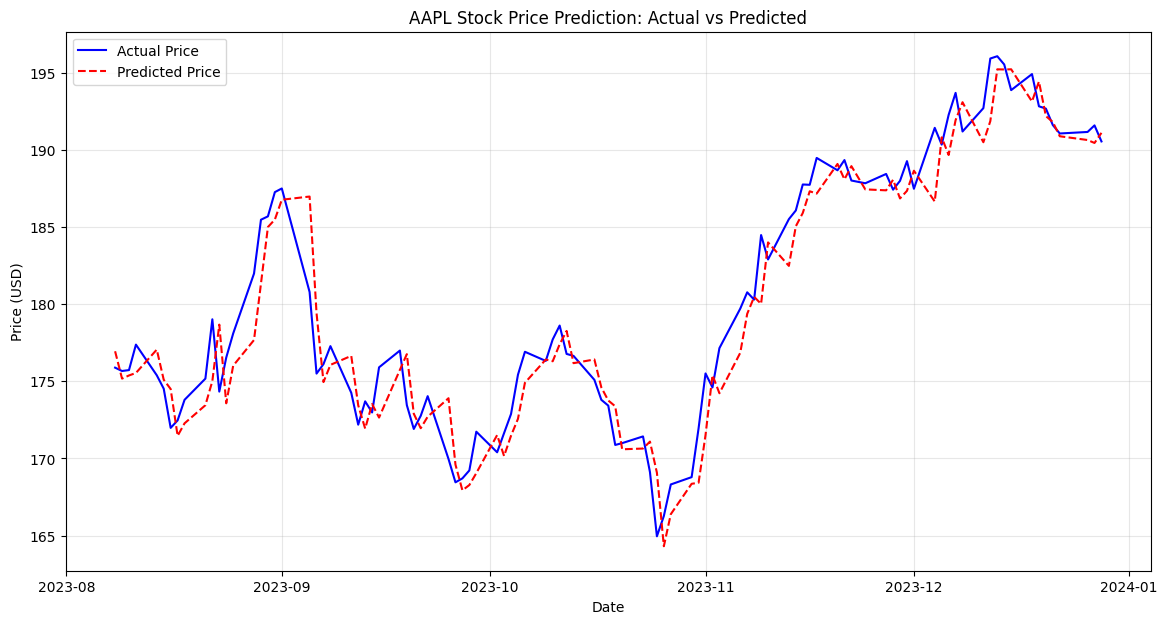

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_test.index, predictions, label='Predicted Price', color='red', linestyle='--', linewidth=1.5)

plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()